# Penerapan Logistic Regression dalam Klasifikasi Diagnosis Kanker Payudara Berdasarkan Karakteristik Sel Tumor

## Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc

%matplotlib inline
sns.set_style('whitegrid')

## Data Understanding

In [ ]:
df = pd.read_csv('Cancer_Data.csv')

print("--- Lima Baris Pertama Data ---")
display(df.head())

print("\n--- Ringkasan Informasi Data ---")
df.info()

print("\n--- Jumlah Missing Value ---")
missing = pd.DataFrame({
    'Missing Value': df.isnull().sum()
})

display(missing)

print("\n--- Statistik Deskriptif ---")
display(df.describe())

--- Lima Baris Pertama Data ---


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



--- Ringkasan Informasi Data ---
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  per

,Missing Value
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0



--- Statistik Deskriptif ---


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


## Data Preprocessing

In [ ]:
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})                                                                                                                                                                               


print("Distribusi Kelas Target:")
print(df['diagnosis'].value_counts())

Distribusi Kelas Target:
diagnosis
0    357
1    212
Name: count, dtype: int64


## Exploratory Data Analysis - EDA

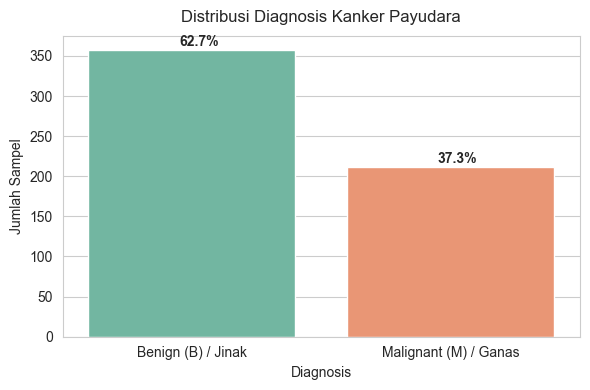

Detail Distribusi Jumlah Pasien:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='diagnosis', data=df, hue='diagnosis', palette='Set2', legend=False)

plt.xticks([0, 1], ['Benign (B) / Jinak', 'Malignant (M) / Ganas'])
plt.title('Distribusi Diagnosis Kanker Payudara', fontsize=12, pad=10)
plt.xlabel('Diagnosis', fontsize=10)
plt.ylabel('Jumlah Sampel', fontsize=10)

total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x_pos = p.get_x() + p.get_width() / 2 - 0.05
    y_pos = p.get_height() + 5
    ax.annotate(percentage, (x_pos, y_pos), fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

print("Detail Distribusi Jumlah Pasien:")
print(df['diagnosis'].value_counts())

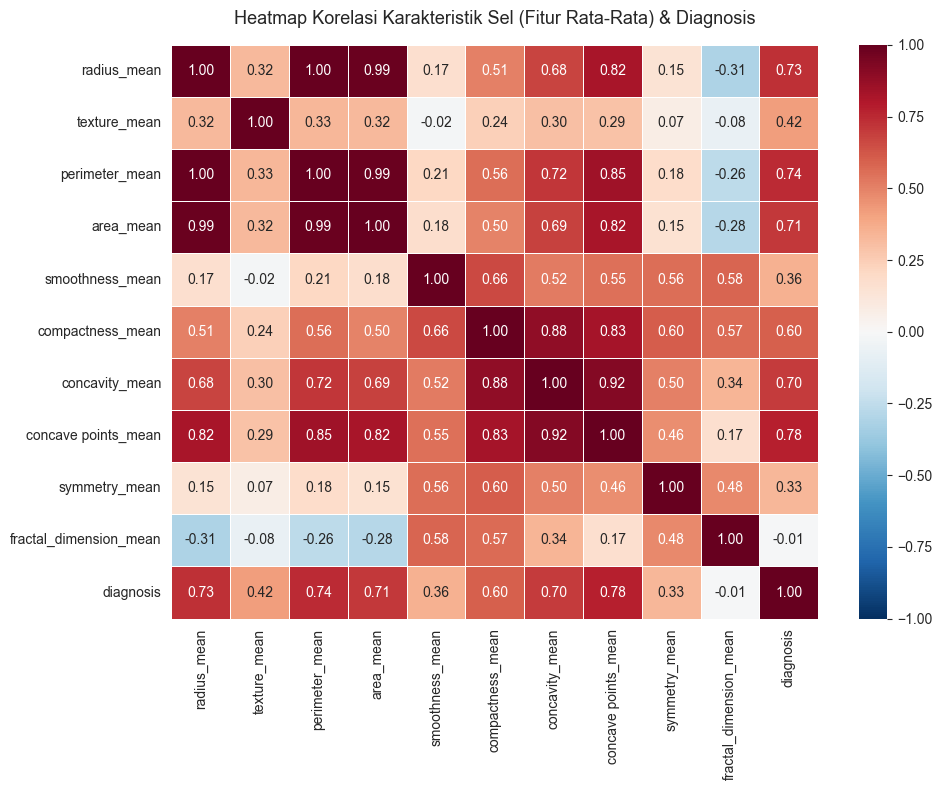

In [ ]:
mean_features = [col for col in df.columns if '_mean' in col]

corr_matrix = df[mean_features + ['diagnosis']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,             
    cmap='RdBu_r',          
    fmt='.2f',              
    linewidths=0.5,         
    vmin=-1, vmax=1         
)

plt.title('Heatmap Korelasi Karakteristik Sel (Fitur Rata-Rata) & Diagnosis', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

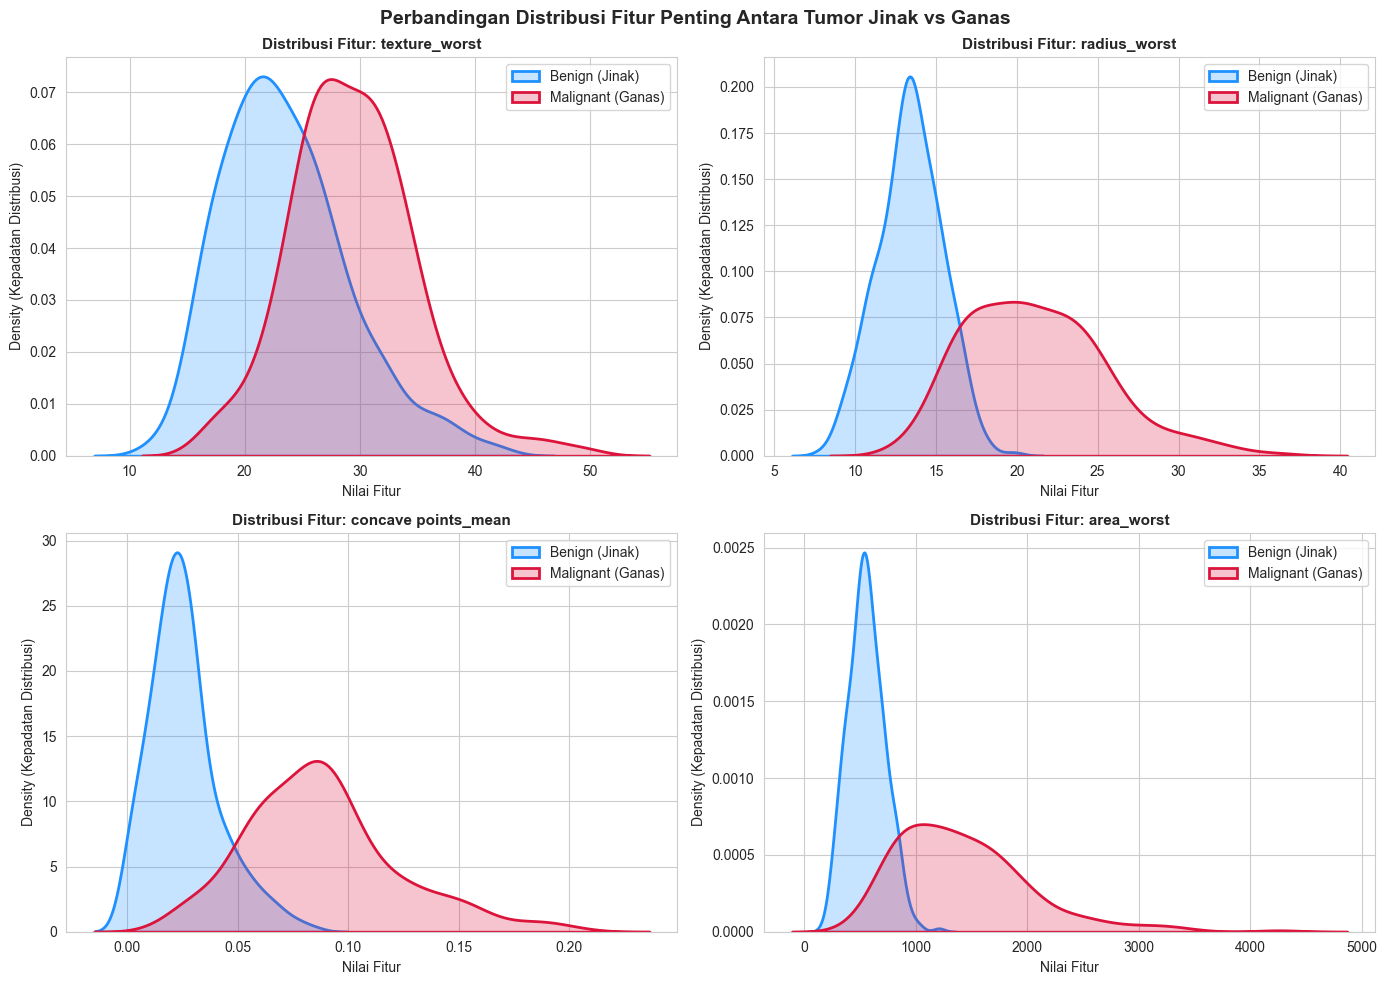

In [ ]:
fitur_penting = ['texture_worst', 'radius_worst', 'concave points_mean', 'area_worst']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(fitur_penting):
    sns.kdeplot(
        data=df[df['diagnosis'] == 0], 
        x=feature, 
        fill=True,            
        label='Benign (Jinak)', 
        color='dodgerblue', 
        ax=axes[i],
        linewidth=2
    )
    sns.kdeplot(
        data=df[df['diagnosis'] == 1], 
        x=feature, 
        fill=True,           
        label='Malignant (Ganas)', 
        color='crimson', 
        ax=axes[i],
        linewidth=2
    )
    
    axes[i].set_title(f'Distribusi Fitur: {feature}', fontsize=11, weight='bold')
    axes[i].set_xlabel('Nilai Fitur')
    axes[i].set_ylabel('Density (Kepadatan Distribusi)')
    axes[i].legend()

plt.suptitle('Perbandingan Distribusi Fitur Penting Antara Tumor Jinak vs Ganas', fontsize=14, y=0.98, weight='bold')
plt.tight_layout()
plt.show()

## Pembagian Data dengan K-Fold Cross Validation & Standardisasi Fitur

In [ ]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Jumlah fold yang digunakan (bisa diganti 5 atau 10)
N_SPLITS = 10

# StratifiedKFold menjaga proporsi kelas (Benign/Malignant) tetap seimbang di setiap fold
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Pipeline memastikan StandardScaler di-fit HANYA pada data train tiap fold
# (mencegah data leakage dari data test ke proses scaling)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=10000, random_state=42))
])

print(f"Skema Validasi: Stratified {N_SPLITS}-Fold Cross Validation")
print(f"Total Sampel: {X.shape[0]}")
print(f"Rata-rata sampel test per fold: {X.shape[0] // N_SPLITS} sampel")

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    print(f"Fold {fold_idx}: train={len(train_idx)} sampel, test={len(test_idx)} sampel")

## Pelatihan Model Logistic Regression dengan Cross Validation

In [ ]:
# Prediksi out-of-fold: setiap sampel diprediksi oleh model yang TIDAK dilatih dengan sampel tersebut
y_pred = cross_val_predict(pipeline, X, y, cv=skf, method='predict')
y_prob = cross_val_predict(pipeline, X, y, cv=skf, method='predict_proba')[:, 1]

# Skor akurasi per fold, untuk melihat konsistensi performa model antar fold
fold_accuracies = cross_val_score(pipeline, X, y, cv=skf, scoring='accuracy')

print("Model Logistic Regression berhasil dilatih dengan Cross Validation!\n")
print("Akurasi per Fold:")
for i, acc in enumerate(fold_accuracies, start=1):
    print(f"  Fold {i}: {acc * 100:.2f}%")
print(f"\nRata-rata Akurasi: {fold_accuracies.mean() * 100:.2f}%")
print(f"Standar Deviasi  : {fold_accuracies.std() * 100:.2f}%")

## Evaluasi Metrik & Confusion Matrix

In [ ]:
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

print("--- HASIL EVALUASI (AGREGAT DARI SELURUH FOLD / OUT-OF-FOLD) ---\n")
print(f"Akurasi Model  : {accuracy * 100:.2f}%")
print(f"Precision      : {precision * 100:.2f}%")
print(f"Recall         : {recall * 100:.2f}%")
print(f"F1-Score       : {f1 * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y, y_pred, target_names=['Benign (B)', 'Malignant (M)']))

conf_matrix = confusion_matrix(y, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (B)', 'Malignant (M)'], 
            yticklabels=['Benign (B)', 'Malignant (M)'])
plt.title(f'Confusion Matrix - Logistic Regression ({N_SPLITS}-Fold CV, Out-of-Fold)')
plt.xlabel('Label Prediksi')
plt.ylabel('Label Aktual')
plt.show()

## Visualisasi Kurva ROC-AUC

In [ ]:
fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title(f'ROC Curve - Logistic Regression ({N_SPLITS}-Fold CV, Out-of-Fold)')
plt.legend(loc="lower right")
plt.show()

## Analisis Koefisien Logistic Regression

In [ ]:
fitur_terkuat = ['texture_worst', 'radius_se', 'symmetry_worst', 'concave points_mean', 'concavity_worst']

X_top = df[fitur_terkuat]
y_top = df['diagnosis']

scaler = StandardScaler()
X_top_scaled = scaler.fit_transform(X_top)

logr = LogisticRegression(max_iter=10000, random_state=42)
logr.fit(X_top_scaled, y_top)

log_odds = logr.coef_[0]

odds = np.exp(log_odds)

df_odds_result = pd.DataFrame({
    'Fitur': fitur_terkuat,
    'Log-Odds (Coef)': log_odds,
    'Odds Ratio (exp)': odds
})

print("--- HASIL PERHITUNGAN ODDS RATIO ---")
display(df_odds_result)

--- HASIL PERHITUNGAN ODDS RATIO ---


,Fitur,Log-Odds (Coef),Odds Ratio (exp)
0,texture_worst,1.562865,4.772477
1,radius_se,1.481369,4.398963
2,symmetry_worst,0.860478,2.364291
3,concave points_mean,3.184970,24.166556
4,concavity_worst,0.225875,1.253420


In [ ]:
fitur_terkuat = ['texture_worst', 'radius_se', 'symmetry_worst', 'concave points_mean', 'concavity_worst']

X_top = df[fitur_terkuat]
y_top = df['diagnosis']

scaler = StandardScaler()
X_top_scaled = scaler.fit_transform(X_top)

logr = LogisticRegression(max_iter=10000, random_state=42)
logr.fit(X_top_scaled, y_top)

def logit2prob(model, X_data):
    log_odds = (X_data @ model.coef_[0]) + model.intercept_[0]
    
    odds = np.exp(log_odds)
    
    probability = odds / (1 + odds)
    return probability

probabilitas_kanker = logit2prob(logr, X_top_scaled[:5])

df_hasil_prob = pd.DataFrame({
    'Diagnosis Asli (Target)': df['diagnosis'].iloc[:5].map({1: 'Malignant (Ganas)', 0: 'Benign (Jinak)'}),
    'Probabilitas Hasil Fungsi (%)': probabilitas_kanker * 100,
    'Prediksi Model Sklearn': logr.predict(X_top_scaled[:5])
})

print("--- PREDIKSI PROBABILITAS MANUAL VS SKLEARN (5 SAMPEL PERTAMA) ---")
display(df_hasil_prob)

--- PREDIKSI PROBABILITAS MANUAL VS SKLEARN (5 SAMPEL PERTAMA) ---


,Diagnosis Asli (Target),Probabilitas Hasil Fungsi (%),Prediksi Model Sklearn
0,Malignant (Ganas),99.999266,1
1,Malignant (Ganas),73.389246,1
2,Malignant (Ganas),99.985002,1
3,Malignant (Ganas),99.996695,1
4,Malignant (Ganas),94.684233,1
